<a href="https://colab.research.google.com/github/Shinevenbrighter/El-problema-The-Knights-tour/blob/main/Actividad_5_1_Implementaci%C3%B3n_backtracking_El_problema_The_Knight%E2%80%99s_tour_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tecnológico de Monterrey Campus Toluca

Actividad 5.1 Implementación backtracking: El problema The Knight’s tour.

Alumna: Valentina Tejeda Fuentes A01771768

Materia: Análisis y diseño de algoritmos avanzados

Grupo: 601

Profesor: Marcial Roberto Leyva Fernandez

##Introducción

El problema del recorrido del caballo (Knight’s Tour) es un clásico de la teoría de grafos y de la programación recursiva. Consiste en determinar una secuencia de movimientos de un caballo de ajedrez sobre un tablero de tamaño
𝑛
×
𝑛
, de forma que visite cada casilla exactamente una vez. (GeeksforGeeks, 2011)

En este proyecto se implementó una versión optimizada con backtracking, donde el caballo recorre un tablero lógico de 5×5 representado dentro de una matriz 7×7 (Se pone más para el padding y revisar los límites). El algoritmo explora todas las rutas posibles de manera recursiva, retrocediendo cada vez que encuentra un camino sin salida, hasta encontrar un recorrido completo que cumpla la condición de visitar todas las celdas una sola vez.

Se utilizó una matriz de adyacencia para modelar los movimientos válidos del caballo como un grafo, junto con una semilla aleatoria (seed) que permite variar el orden de los movimientos y, por tanto, obtener diferentes soluciones. Después de correr el código, el resultado se visualiza mediante un GIF animado descargable que muestra paso a paso el recorrido realizado por el caballo.

##Código con backtracking

In [ ]:
import numpy as np
import random
from PIL import Image, ImageDraw, ImageFont
import os

# --- CONFIGURACIÓN ---
N = 7               # Tamaño total con padding
VALID_RANGE = range(1, 6)  # Tablero lógico 5x5
SEED = 10        # Cambia para obtener diferentes recorridos

# --- MOVIMIENTOS POSIBLES DEL CABALLO ---
MOVS = [(2, 1), (1, 2), (-1, 2), (-2, 1),
        (-2, -1), (-1, -2), (1, -2), (2, -1)]

# --- CREAR MATRIZ DE ADYACENCIA ---
adj = np.zeros((N * N, N * N), dtype=int)

def coord_to_node(i, j):
    return i * N + j

def es_valido(i, j):
    return i in VALID_RANGE and j in VALID_RANGE

for i in VALID_RANGE:
    for j in VALID_RANGE:
        src = coord_to_node(i, j)
        for dx, dy in MOVS:
            ni, nj = i + dx, j + dy
            if es_valido(ni, nj):
                dst = coord_to_node(ni, nj)
                adj[src, dst] = 1

# --- VARIABLES GLOBALES PARA CONTAR ---
iteraciones = 0
truncamientos = 0

# --- BACKTRACKING ---
def backtrack(i, j, paso, visitado, solucion):
    global iteraciones, truncamientos
    iteraciones += 1

    if paso == 25:
        solucion.append((i, j))
        return True

    movimientos = MOVS[:]
    random.shuffle(movimientos)
    for dx, dy in movimientos:
        ni, nj = i + dx, j + dy
        if es_valido(ni, nj) and not visitado[ni, nj]:
            visitado[ni, nj] = True
            if backtrack(ni, nj, paso + 1, visitado, solucion):
                solucion.append((i, j))
                return True
            # Retroceso
            visitado[ni, nj] = False
            truncamientos += 1

    return False

# --- FUNCIÓN PRINCIPAL ---
def knight_tour():
    global iteraciones, truncamientos
    iteraciones = 0
    truncamientos = 0

    visitado = np.zeros((N, N), dtype=bool)
    solucion = []

    # Punto de inicio aleatorio dentro del 5x5
    inicio = (1,5)

    exito = backtrack(inicio[0], inicio[1], 1, visitado, solucion)
    solucion = solucion[::-1]

    print("\nFINALIZADO -------------------------------------------------------------------------------------------------------")
    print(f"Seed usada: {SEED}")
    print(f"Inicio aleatorio: {inicio}")
    print(f"Iteraciones realizadas: {iteraciones}")
    print(f"Truncamientos realizados: {truncamientos}")

    if exito:
        print("✅ Recorrido completo encontrado.")
        print("Camino (coordenadas i,j):")
        print(solucion)
        generar_gif(solucion)
    else:
        print("❌ No se encontró recorrido completo.")



##GIF

In [ ]:

# --- GENERAR GIF (estilo PIL) ---
def generar_gif(solucion, n=5, filename="knight_tour.gif"):
    square_size = 100
    margin = int(square_size * 0.15)
    color1 = (222, 76, 138)
    color2 = (250, 251, 253)
    folder = "frames_knight"
    os.makedirs(folder, exist_ok=True)

    frames = []
    visitados = []

    for step, (i, j) in enumerate(solucion):
        visitados.append((i, j))
        img_array = np.zeros((n * square_size, n * square_size, 3), dtype=np.uint8)

        # Dibujar tablero
        for row in range(n):
            for col in range(n):
                y0, y1 = row * square_size, (row + 1) * square_size
                x0, x1 = col * square_size, (col + 1) * square_size
                color = color1 if (row + col) % 2 == 0 else color2
                img_array[y0:y1, x0:x1] = color

        img = Image.fromarray(img_array)
        draw = ImageDraw.Draw(img)

        # Dibujar pasos recorridos
        for idx, (pi, pj) in enumerate(visitados):
            r, c = pi - 1, pj - 1
            x0 = c * square_size + margin
            y0 = r * square_size + margin
            x1 = (c + 1) * square_size - margin
            y1 = (r + 1) * square_size - margin
            draw.line((x0, y0, x1, y1), fill=(255, 0, 0), width=5)
            draw.line((x0, y1, x1, y0), fill=(255, 0, 0), width=5)

        # Número del paso actual
        draw.text((10, 10), f"Paso {step+1}/{len(solucion)}", fill=(0, 0, 255))

        frame_path = f"{folder}/frame_{step:02d}.png"
        img.save(frame_path)
        frames.append(Image.open(frame_path))

    # Crear GIF
    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=400,
        loop=0
    )

    print(f"🎞️ GIF generado: {filename}")



##Main

In [ ]:
# --- EJECUCIÓN ---
if __name__ == "__main__":
    knight_tour()


FINALIZADO -------------------------------------------------------------------------------------------------------
Seed usada: 10
Inicio aleatorio: (1, 5)
Iteraciones realizadas: 11379
Truncamientos realizados: 11354
✅ Recorrido completo encontrado.
Camino (coordenadas i,j):
[(1, 5), (3, 4), (1, 5), (2, 3), (3, 5), (1, 4), (2, 2), (4, 1), (3, 3), (5, 4), (4, 2), (2, 1), (1, 3), (2, 5), (4, 4), (5, 2), (3, 1), (1, 2), (2, 4), (4, 5), (5, 3), (3, 2), (5, 1), (4, 3), (5, 5)]
🎞️ GIF generado: knight_tour.gif


##Resultados

**Ejemplo de salida**

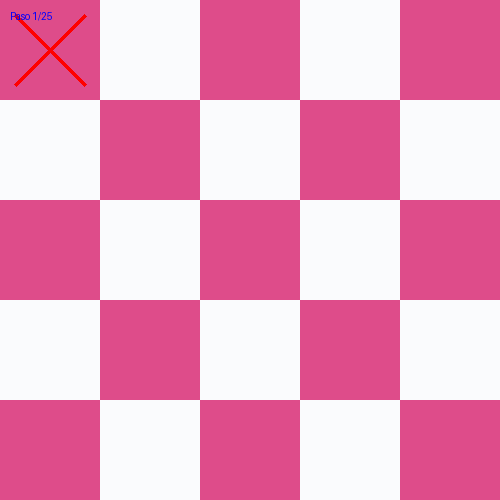



Tabla de casos de prueba

| Exp | Seed | Inicio aleatorio | Iteraciones | Truncamiento | RUTA |
|-----|------|------------------|-------------|--------------|------|
| 1   | 0   | (4,4)            | 86076       | 86051        |[(4, 4), (5, 2), (3, 3), (2, 5), (1, 3), (2, 1), (4, 2), (5, 4), (3, 5), (1, 4), (2, 2), (4, 1), (5, 3), (4, 5), (2, 4), (1, 2), (3, 1), (4, 3), (5, 5), (3, 4), (1, 5), (2, 3), (1, 1), (3, 2), (5, 1)]|
| 2   | 10  |   (1,5)               |  11379           |    11354          |    [(5, 1), (4, 3), (3, 5), (1, 4), (2, 2), (4, 1), (5, 3), (4, 5), (2, 4), (1, 2), (3, 1), (5, 2), (4, 4), (2, 5), (3, 3), (5, 4), (4, 2), (2, 1), (1, 3), (3, 2), (1, 1), (2, 3), (1, 5), (3, 4), (5, 5)]|
| 3   | 30    |  (0,0)                |5953             |     5928         |   [(0, 0), (1, 2), (3, 1), (2, 3), (1, 1), (3, 2), (4, 4), (5, 2), (3, 3), (2, 5), (1, 3), (2, 1), (4, 2), (5, 4), (3, 5), (1, 4), (2, 2), (4, 1), (5, 3), (4, 5), (2, 4), (4, 3), (5, 5), (3, 4), (1, 5)]
   |
| 4   | 50   |   (1,5)               |       706      |       681       | [(1, 5), (2, 3), (1, 1), (3, 2), (5, 1), (4, 3), (2, 4), (1, 2), (3, 1), (5, 2), (4, 4), (2, 5), (3, 3), (4, 5), (5, 3), (4, 1), (2, 2), (1, 4), (3, 5), (5, 4), (4, 2), (2, 1), (1, 3), (3, 4), (1, 5)] |

Los resultados muestran que el cambio en la seed y el punto de inicio alteran significativamente el número de iteraciones y retrocesos necesarios para hallar una solución válida.

El experimento 1, con una semilla de 0 y un inicio en el centro del tablero, requirió más de 86,000 iteraciones, mientras que el experimento 4 logró encontrar una ruta completa en tan solo 706 iteraciones. Esto evidencia la sensibilidad del backtracking al orden de exploración, así como la complejidad combinatoria del problema.

Además, todas las rutas encontradas recorren los 25 nodos válidos del tablero, lo que demuestra que el algoritmo cumple su objetivo de visitar todas las posiciones posibles sin repeticiones.

##Conclusión

El algoritmo de backtracking demostró ser una herramienta eficaz para resolver el problema del recorrido del caballo, ya que garantiza encontrar una solución completa siempre que exista, ya que el caballo se regresa cada vez que va a tocar el padding o límite, ahi es cuando entra el backtracking.

El uso de una matriz de adyacencia permitió representar claramente las transiciones válidas entre celdas y analizar el problema desde una perspectiva de grafos. Asimismo, la inclusión de una semilla aleatoria permitió explorar distintas configuraciones de recorrido, evidenciando cómo el orden de los movimientos influye directamente en la complejidad y el número de iteraciones en la búsqueda.

La visualización mediante GIF facilitó la interpretación del recorrido y la validación de los resultados. En conjunto, este trabajo demuestra cómo técnicas de exploración sistemática y visualización pueden integrarse para abordar problemas combinatorios de forma estructurada y comprensible.